# 🏦 Topi FinOps / FP&A Analytics Pipeline
**Device-as-a-Service | New Segment Analysis | Complaints × Lifecycle × Billing**

---
### Pipeline Overview
| Step | Section | Deliverable |
|------|---------|-------------|
| A | Data Ingestion | Mapped logical tables |
| B | Data Quality | `data_quality_report.csv`, `DATA_QUALITY_SUMMARY.md` |
| C | DCB Master Table | `dcb_master_table.csv` |
| D | Reconciliation | `exceptions_report.csv`, `exceptions_summary.csv` |
| E | KPI Framework | `kpi_monthly.csv`, `kpi_segment.csv` |
| F | Dashboard Charts | PNG exports |
| G | Executive Story | `EXEC_SUMMARY.md` |
| H | Segment Scorecard | `segment_scorecard.csv` |
| I | Early Warning System | `early_warning_flags.csv`, `EARLY_WARNING_RULES.md` |
| J | Financial Impact Model | `financial_impact_model.csv`, `FINANCIAL_IMPACT_ASSUMPTIONS.md` |
| Z | ZIP Archive | `topi_finops_project_artifacts.zip` |

> **Local file:** `C:\\Nirva\\2026\\Github\\Topi\\Topi.xlsx`  
> **Upload via Colab file picker in Cell A1 below.**

---
## ⚙️ 0. Setup — Install / Import Libraries & Create Output Folders

In [1]:
# ── 0. SETUP ────────────────────────────────────────────────────────────────
import os, sys, re, zipfile, warnings, textwrap
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.patches import FancyBboxPatch

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:,.2f}'.format)
matplotlib.rcParams.update({
    'figure.dpi': 120,
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
})

# ── Output folders ───────────────────────────────────────────────────────────
DIRS = [
    '/content/outputs',
    '/content/outputs/charts',
    '/content/docs',
]
for d in DIRS:
    os.makedirs(d, exist_ok=True)

OUT   = Path('/content/outputs')
CHART = Path('/content/outputs/charts')
DOCS  = Path('/content/docs')

print('✅ Libraries loaded | Output folders ready')
print(f'   {OUT}  |  {CHART}  |  {DOCS}')


✅ Libraries loaded | Output folders ready
   /content/outputs  |  /content/outputs/charts  |  /content/docs


---
## A. Data Ingestion
### A1 — Upload `Topi.xlsx` from your local machine

In [2]:
# ── A1. UPLOAD ───────────────────────────────────────────────────────────────
from google.colab import files

print('📂 Please upload Topi.xlsx when the picker appears...')
uploaded = files.upload()

# Find the xlsx file (handles if user renames it)
xlsx_candidates = [k for k in uploaded.keys() if k.lower().endswith('.xlsx')]
if not xlsx_candidates:
    raise FileNotFoundError('No .xlsx file detected. Please re-run and upload Topi.xlsx.')

XLSX_PATH = xlsx_candidates[0]
print(f'✅ Loaded: {XLSX_PATH}  ({len(uploaded[XLSX_PATH]):,} bytes)')


📂 Please upload Topi.xlsx when the picker appears...


Saving Topi.xlsx to Topi.xlsx
✅ Loaded: Topi.xlsx  (107,291 bytes)


### A2 — Read all sheets & auto-map to logical tables

In [3]:
# ── A2. SHEET DETECTION & FUZZY TABLE MAPPING ────────────────────────────────
import re

LOGICAL_TABLES = {
    'devices': {
        'must': ['device_id'],
        'nice': ['serial', 'sku', 'model', 'country', 'partner',
                 'ship_date', 'activation_date', 'purchase_cost_eur'],
    },
    'contracts': {
        'must': ['contract_id', 'device_id'],
        'nice': ['serial', 'customer', 'country', 'partner', 'plan',
                 'monthly_price_eur', 'contract_start', 'contract_end', 'contract_status'],
    },
    'lifecycle_events': {
        'must': ['device_id', 'event_date', 'event_type'],
        'nice': ['serial'],
    },
    'tickets': {
        'must': ['ticket_id', 'device_id'],
        'nice': ['contract_id', 'customer', 'sku', 'issue_category',
                 'severity', 'ticket_date', 'resolution_days', 'resolved'],
    },
    'invoices': {
        'must': ['invoice_id', 'contract_id'],
        'nice': ['device_id', 'invoice_month', 'billed_amount_eur',
                 'collected_amount_eur', 'dpd', 'billing_status'],
    },
    'data_dictionary': {
        'must': [],
        'nice': ['field', 'description', 'table'],
    },
}

def normalise_col(c):
    return re.sub(r'[\s\-]+', '_', str(c).lower().strip())

def score_sheet(df_cols, logical):
    norm = {normalise_col(c) for c in df_cols}
    must_hits  = sum(1 for c in logical['must'] if c in norm)
    must_total = max(len(logical['must']), 1)
    nice_hits  = sum(1 for c in logical['nice'] if c in norm)
    nice_total = max(len(logical['nice']), 1)
    return (must_hits / must_total) * 0.7 + (nice_hits / nice_total) * 0.3

# Read all sheets
xl = pd.ExcelFile(XLSX_PATH)
raw_sheets = {}
for sname in xl.sheet_names:
    try:
        df = xl.parse(sname)
        df.columns = [normalise_col(c) for c in df.columns]
        raw_sheets[sname] = df
        print(f'  📄 Sheet "{sname}": {df.shape[0]:,} rows x {df.shape[1]} cols')
    except Exception as e:
        print(f'  ⚠️  Could not parse sheet "{sname}": {e}')

print(f'\n✅ {len(raw_sheets)} sheets loaded')

# Greedy best-match assignment
assignment = {}
used_sheets = set()

for logical_name, defn in LOGICAL_TABLES.items():
    best_sheet, best_score = None, -1
    for sname, df in raw_sheets.items():
        if sname in used_sheets:
            continue
        s = score_sheet(df.columns, defn)
        if s > best_score:
            best_score, best_sheet = s, sname
    if best_sheet and best_score >= 0.4:
        assignment[logical_name] = best_sheet
        used_sheets.add(best_sheet)
        print(f'  ✅ {logical_name:<22} <- "{best_sheet}"  (score={best_score:.2f})')
    else:
        print(f'  ⚠️  {logical_name:<22}  NO match (best={best_score:.2f})')

TABLES = {lname: raw_sheets[sname].copy() for lname, sname in assignment.items()}

def get_table(name):
    return TABLES.get(name, pd.DataFrame())

devices   = get_table('devices')
contracts = get_table('contracts')
lifecycle = get_table('lifecycle_events')
tickets   = get_table('tickets')
invoices  = get_table('invoices')

print('\n── Shape summary ──────────────────────────────────')
for k, df in TABLES.items():
    print(f'  {k:<22}: {df.shape[0]:>6,} rows x {df.shape[1]:>3} cols')


  📄 Sheet "contracts": 240 rows x 11 cols
  📄 Sheet "DATA_DICTIONARY": 12 rows x 3 cols
  📄 Sheet "devices": 240 rows x 9 cols
  📄 Sheet "invoices": 538 rows x 8 cols
  📄 Sheet "lifecycle_events": 356 rows x 4 cols
  📄 Sheet "tickets": 48 rows x 10 cols
  📄 Sheet "Sheet1": 0 rows x 0 cols

✅ 7 sheets loaded
  ✅ devices                <- "devices"  (score=1.00)
  ✅ contracts              <- "contracts"  (score=1.00)
  ✅ lifecycle_events       <- "lifecycle_events"  (score=1.00)
  ✅ tickets                <- "tickets"  (score=1.00)
  ✅ invoices               <- "invoices"  (score=1.00)
  ⚠️  data_dictionary         NO match (best=0.00)

── Shape summary ──────────────────────────────────
  devices               :    240 rows x   9 cols
  contracts             :    240 rows x  11 cols
  lifecycle_events      :    356 rows x   4 cols
  tickets               :     48 rows x  10 cols
  invoices              :    538 rows x   8 cols


---
## B. Data Cleaning & Validation

In [4]:
# ── B. DATA QUALITY ──────────────────────────────────────────────────────────

DATE_COLS = {
    'devices':           ['ship_date', 'activation_date'],
    'contracts':         ['contract_start', 'contract_end'],
    'lifecycle_events':  ['event_date'],
    'tickets':           ['ticket_date'],
    'invoices':          ['invoice_month'],
}
NUMERIC_COLS = {
    'devices':   ['purchase_cost_eur'],
    'contracts': ['monthly_price_eur'],
    'invoices':  ['billed_amount_eur', 'collected_amount_eur', 'dpd'],
    'tickets':   ['resolution_days'],
}

dq_records = []

def log_dq(table, check, count, detail=''):
    dq_records.append({'table': table, 'check': check,
                       'issue_count': count, 'detail': detail})

for lname, df in TABLES.items():
    if df.empty:
        continue
    # 1. Missing values
    miss = df.isnull().sum()
    for col, cnt in miss[miss > 0].items():
        log_dq(lname, 'missing_values', cnt, f'column={col}')
    # 2. Duplicates
    dup_cnt = df.duplicated().sum()
    log_dq(lname, 'duplicate_rows', dup_cnt)
    TABLES[lname] = df.drop_duplicates().reset_index(drop=True)
    # 3. Date parsing
    for col in DATE_COLS.get(lname, []):
        if col in TABLES[lname].columns:
            before = TABLES[lname][col].isna().sum()
            TABLES[lname][col] = pd.to_datetime(
                TABLES[lname][col], errors='coerce', infer_datetime_format=True)
            unparseable = TABLES[lname][col].isna().sum() - before
            if unparseable > 0:
                log_dq(lname, 'unparseable_dates', unparseable, f'column={col}')
    # 4. Negative amounts
    for col in NUMERIC_COLS.get(lname, []):
        if col in TABLES[lname].columns:
            TABLES[lname][col] = pd.to_numeric(TABLES[lname][col], errors='coerce')
            neg = (TABLES[lname][col] < 0).sum()
            if neg > 0:
                log_dq(lname, 'negative_amounts', neg, f'column={col}')

# Re-assign cleaned references
devices   = TABLES.get('devices',           pd.DataFrame())
contracts = TABLES.get('contracts',         pd.DataFrame())
lifecycle = TABLES.get('lifecycle_events',  pd.DataFrame())
tickets   = TABLES.get('tickets',           pd.DataFrame())
invoices  = TABLES.get('invoices',          pd.DataFrame())

# 5. Contract date logic
if not contracts.empty and 'contract_start' in contracts and 'contract_end' in contracts:
    bad_dates = (contracts['contract_end'] < contracts['contract_start']).sum()
    log_dq('contracts', 'end_before_start', bad_dates)

# 6. Orphan device FK check
if not contracts.empty and not devices.empty:
    if 'device_id' in contracts.columns and 'device_id' in devices.columns:
        orphans = (~contracts['device_id'].isin(devices['device_id'])).sum()
        log_dq('contracts', 'orphan_device_id', orphans, 'device_id not in devices')

# 7. Invoice amount outliers (>3 STD)
if not invoices.empty and 'billed_amount_eur' in invoices.columns:
    mu = invoices['billed_amount_eur'].mean()
    sigma = invoices['billed_amount_eur'].std()
    out = (np.abs(invoices['billed_amount_eur'] - mu) > 3 * sigma).sum()
    log_dq('invoices', 'billed_amount_outliers_3std', out)

dq_df = pd.DataFrame(dq_records)
dq_df.to_csv(OUT / 'data_quality_report.csv', index=False)

total_issues = dq_df['issue_count'].sum()
print(f'✅ Data quality checks complete — {len(dq_df)} checks, {total_issues:,} total issues')
display(dq_df[dq_df['issue_count'] > 0])


✅ Data quality checks complete — 10 checks, 43 total issues


,table,check,issue_count,detail
0,devices,missing_values,4,column=activation_date
5,invoices,missing_values,39,column=invoice_id


In [5]:
# ── B2. DATA QUALITY SUMMARY MARKDOWN ───────────────────────────────────────

lines = [
    '# Data Quality Summary\n',
    f'**Generated:** {datetime.now().strftime("%Y-%m-%d %H:%M")}  \n',
    '**Source file:** Topi.xlsx  \n\n',
    '## Overview\n',
    '| Table | Total Issues |\n',
    '|-------|--------------|\n',
]
for tname, grp in dq_df.groupby('table'):
    lines.append(f'| {tname} | {grp["issue_count"].sum():,} |\n')

lines += [
    '\n## Detail by Check Type\n',
    '| Table | Check | Count | Detail |\n',
    '|-------|-------|-------|--------|\n',
]
for _, row in dq_df[dq_df['issue_count'] > 0].iterrows():
    lines.append(f'| {row.table} | {row.check} | {row.issue_count:,} | {row.detail} |\n')

lines += [
    '\n## Recommended Actions\n',
    '- Investigate and impute/drop rows with missing primary keys before modeling.\n',
    '- Align contract_end dates where they precede contract_start.\n',
    '- Review orphan device_id records — may indicate unmapped data sources.\n',
    '- Validate negative billing amounts with source ERP export.\n',
    '- Confirm outlier invoice amounts are not test/correction entries.\n',
]

(DOCS / 'DATA_QUALITY_SUMMARY.md').write_text(''.join(lines))
print('✅ DATA_QUALITY_SUMMARY.md written')


✅ DATA_QUALITY_SUMMARY.md written


---
## C. DCB Master Table (Device → Contract → Billing)

In [6]:
# ── C. BUILD DCB MASTER TABLE ────────────────────────────────────────────────

# C1: Merge devices -> contracts
if not devices.empty and not contracts.empty:
    dc = contracts.merge(devices, on='device_id', how='left', suffixes=('', '_dev'))
else:
    dc = contracts.copy() if not contracts.empty else devices.copy()

# C2: Expand to monthly grain
def expand_monthly(df, start_col='contract_start', end_col='contract_end'):
    cap_date = pd.Timestamp.today().replace(day=1)
    rows = []
    for _, r in df.iterrows():
        s = r.get(start_col)
        e = r.get(end_col)
        if pd.isna(s):
            continue
        e = min(e, cap_date) if pd.notna(e) else cap_date
        for m in pd.date_range(s, e, freq='MS'):
            row = r.to_dict()
            row['invoice_month'] = m
            rows.append(row)
    return pd.DataFrame(rows)

if not dc.empty and 'contract_start' in dc.columns:
    dc_monthly = expand_monthly(dc)
    dc_monthly['invoice_month'] = pd.to_datetime(dc_monthly['invoice_month'])
    print(f'  DC monthly expanded: {len(dc_monthly):,} rows')
else:
    dc_monthly = dc.copy()
    print('  ⚠️  Skipped monthly expansion (missing contract_start)')

# C3: Merge invoices
if not invoices.empty and not dc_monthly.empty:
    if 'invoice_month' in invoices.columns:
        invoices['invoice_month'] = pd.to_datetime(invoices['invoice_month'])
    merge_keys = [k for k in ['contract_id', 'device_id', 'invoice_month']
                  if k in dc_monthly.columns and k in invoices.columns]
    inv_cols = merge_keys + [c for c in
        ['billed_amount_eur', 'collected_amount_eur', 'dpd', 'billing_status', 'invoice_id']
        if c in invoices.columns]
    dcb = dc_monthly.merge(
        invoices[inv_cols].drop_duplicates(subset=merge_keys, keep='first'),
        on=merge_keys, how='left')
else:
    dcb = dc_monthly.copy()

# C4: Enrich with complaint features
if not tickets.empty:
    if 'ticket_date' in tickets.columns:
        tickets['invoice_month'] = pd.to_datetime(
            tickets['ticket_date']).dt.to_period('M').dt.to_timestamp()
    tkt_keys = [k for k in ['device_id', 'invoice_month']
                if k in dcb.columns and k in tickets.columns]
    if tkt_keys:
        tkt_id_col = 'ticket_id' if 'ticket_id' in tickets.columns else tickets.columns[0]
        agg_dict = {tkt_id_col: 'count'}
        if 'resolution_days' in tickets.columns:
            agg_dict['resolution_days'] = 'mean'
        tkt_agg = tickets.groupby(tkt_keys).agg(agg_dict).reset_index()
        tkt_agg.rename(columns={tkt_id_col: 'ticket_count'}, inplace=True)
        if 'resolution_days' in tkt_agg.columns:
            tkt_agg.rename(columns={'resolution_days': 'avg_resolution_days'}, inplace=True)
        dcb = dcb.merge(tkt_agg, on=tkt_keys, how='left')
        dcb['ticket_count'] = dcb['ticket_count'].fillna(0)

# C5: Enrich with lifecycle features
if not lifecycle.empty and 'device_id' in lifecycle.columns and 'event_type' in lifecycle.columns:
    lifecycle['event_date'] = pd.to_datetime(lifecycle.get('event_date', pd.NaT), errors='coerce')
    def lc_agg(g):
        et = g['event_type'].str.lower()
        return pd.Series({
            'repair_count':    et.str.contains('repair|fix', na=False).sum(),
            'swap_count':      et.str.contains('swap|replace|exchange', na=False).sum(),
            'return_count':    et.str.contains('return|rma', na=False).sum(),
            'lc_event_count':  len(g),
            'last_lc_event':   g['event_date'].max(),
        })
    lc_pivot = lifecycle.groupby('device_id').apply(lc_agg).reset_index()
    if 'device_id' in dcb.columns:
        dcb = dcb.merge(lc_pivot, on='device_id', how='left')
        for c in ['repair_count', 'swap_count', 'return_count', 'lc_event_count']:
            if c in dcb.columns:
                dcb[c] = dcb[c].fillna(0)

# C6: Derived columns
if 'billed_amount_eur' in dcb.columns and 'collected_amount_eur' in dcb.columns:
    dcb['uncollected_eur'] = (dcb['billed_amount_eur'] - dcb['collected_amount_eur']).clip(lower=0)
    dcb['collection_rate'] = np.where(
        dcb['billed_amount_eur'] > 0,
        dcb['collected_amount_eur'] / dcb['billed_amount_eur'], np.nan)

if 'contract_status' in dcb.columns:
    dcb['expected_billable'] = dcb['contract_status'].str.lower().isin(
        ['active', 'billable', 'live', 'enabled'])
else:
    dcb['expected_billable'] = True

dcb.to_csv(OUT / 'dcb_master_table.csv', index=False)
print(f'\n✅ DCB master table: {len(dcb):,} rows x {len(dcb.columns)} cols')
print(f'   Exported -> {OUT}/dcb_master_table.csv')
display(dcb.head(3))


  DC monthly expanded: 601 rows

✅ DCB master table: 601 rows x 35 cols
   Exported -> /content/outputs/dcb_master_table.csv


,contract_id,device_id,serial,customer,country,partner,plan,monthly_price_eur,contract_start,contract_end,contract_status,serial_dev,sku,model,country_dev,partner_dev,ship_date,activation_date,purchase_cost_eur,invoice_month,billed_amount_eur,collected_amount_eur,dpd,billing_status,invoice_id,ticket_count,avg_resolution_days,repair_count,swap_count,return_count,lc_event_count,last_lc_event,uncollected_eur,collection_rate,expected_billable
0,C-6074044,D-00001,S40620597,Amsterdam Consulting BV,FR,Retailer A,36M,5639,2026-02-03,2029-01-18,Active,S40620597,LTP-ALPHA-14,AlphaBook 14,FR,Retailer A,2026-02-01,2026-02-03,93498,2026-03-01,NaN,NaN,NaN,NaN,NaN,0.00,NaN,0,0,0,1,2026-02-03,NaN,NaN,True
1,C-0728845,D-00002,S53197648,Amsterdam Consulting BV,DE,Retailer A,36M,451,2026-01-01,2028-12-16,Active,S53197648,LTP-BETA-13,BetaBook 13,DE,Retailer A,2026-01-01,2026-01-01,79823,2026-01-01,451.00,451.00,2.00,Billed,INV-028054988,0.00,NaN,0,0,0,1,2026-01-01,0.00,1.00,True
2,C-0728845,D-00002,S53197648,Amsterdam Consulting BV,DE,Retailer A,36M,451,2026-01-01,2028-12-16,Active,S53197648,LTP-BETA-13,BetaBook 13,DE,Retailer A,2026-01-01,2026-01-01,79823,2026-02-01,451.00,0.00,74.00,Billed,INV-216710891,0.00,NaN,0,0,0,1,2026-01-01,451.00,0.00,True


---
## D. Reconciliation & Exception Flags

In [8]:
# ── D. RECONCILIATION EXCEPTIONS ────────────────────────────────────────────

exc = dcb.copy()

billed_col = 'billed_amount_eur' in exc.columns
has_invoice = exc['billed_amount_eur'] > 0 if billed_col else pd.Series(False, index=exc.index)
has_invoice = has_invoice.fillna(False)
expected_b  = exc['expected_billable'] if 'expected_billable' in exc.columns else pd.Series(True, index=exc.index)

# Flag 1: Expected billable but not invoiced
exc['flag_expected_not_billed'] = expected_b & ~has_invoice

# Flag 2: Not expected billable but invoiced
exc['flag_unexpected_billed'] = ~expected_b & has_invoice

# Flag 3: Returned but still billed
if 'return_count' in exc.columns and billed_col:
    exc['flag_returned_still_billed'] = (exc['return_count'] > 0) & has_invoice
else:
    exc['flag_returned_still_billed'] = False

# Flag 4: Duplicate invoices
if 'invoice_id' in exc.columns and 'contract_id' in exc.columns and 'invoice_month' in exc.columns:
    exc['flag_duplicate_invoice'] = exc.duplicated(
        subset=['contract_id', 'invoice_month'], keep=False) & has_invoice
else:
    exc['flag_duplicate_invoice'] = False

# Flag 5: Paused/cancelled but still billed
if 'billing_status' in exc.columns and billed_col:
    paused = exc['billing_status'].astype(str).str.lower().isin(
        ['paused', 'suspended', 'cancelled', 'cancel', 'stopped'])
    exc['flag_paused_but_billed'] = paused & has_invoice
else:
    exc['flag_paused_but_billed'] = False

flag_cols = [c for c in exc.columns if c.startswith('flag_')]
exc['any_exception'] = exc[flag_cols].any(axis=1)

exceptions_report = exc[exc['any_exception']].copy()
exceptions_report.to_csv(OUT / 'exceptions_report.csv', index=False)

summary_rows = []
for fc in flag_cols:
    subset = exc[exc[fc]]
    eur_impact = subset['billed_amount_eur'].sum() if billed_col else 0
    summary_rows.append({
        'exception_type': fc.replace('flag_', '').replace('_', ' ').title(),
        'record_count': int(exc[fc].sum()),
        'eur_impact': round(eur_impact, 2),
    })
exc_summary = pd.DataFrame(summary_rows)
exc_summary.to_csv(OUT / 'exceptions_summary.csv', index=False)

print('✅ Reconciliation complete')
print(f'   Total exceptions: {exc["any_exception"].sum():,} rows '
      f'({exc["any_exception"].mean()*100:.1f}% of DCB)')
display(exc_summary)


✅ Reconciliation complete
   Total exceptions: 260 rows (43.3% of DCB)


,exception_type,record_count,eur_impact
0,Expected Not Billed,219,0.00
1,Unexpected Billed,41,"176,201.00"
2,Returned Still Billed,36,"151,617.00"
3,Duplicate Invoice,0,0.00
4,Paused But Billed,0,0.00


---
## E. KPI Framework

In [9]:
# ── E. KPI FRAMEWORK ─────────────────────────────────────────────────────────

def build_kpi(df, group_cols):
    agg = {}
    if 'monthly_price_eur' in df.columns: agg['expected_eur']  = ('monthly_price_eur', 'sum')
    if 'billed_amount_eur' in df.columns: agg['invoiced_eur']  = ('billed_amount_eur', 'sum')
    if 'collected_amount_eur' in df.columns: agg['collected_eur'] = ('collected_amount_eur', 'sum')
    if 'ticket_count' in df.columns:     agg['total_tickets'] = ('ticket_count', 'sum')
    if 'repair_count' in df.columns:     agg['total_repairs'] = ('repair_count', 'sum')
    if 'swap_count' in df.columns:       agg['total_swaps']   = ('swap_count', 'sum')
    if 'dpd' in df.columns:              agg['avg_dpd']        = ('dpd', 'mean')
    if 'contract_id' in df.columns:      agg['contract_count'] = ('contract_id', 'nunique')
    for fc in [c for c in df.columns if c.startswith('flag_')]:
        agg[fc + '_count'] = (fc, 'sum')
    if not agg:
        return pd.DataFrame()
    valid_groups = [g for g in group_cols if g in df.columns]
    if not valid_groups:
        return pd.DataFrame()
    kpi = df.groupby(valid_groups).agg(**agg).reset_index()
    if 'invoiced_eur' in kpi and 'expected_eur' in kpi:
        kpi['billing_coverage_pct'] = np.where(
            kpi['expected_eur'] > 0, kpi['invoiced_eur'] / kpi['expected_eur'] * 100, np.nan)
    if 'collected_eur' in kpi and 'invoiced_eur' in kpi:
        kpi['collection_rate_pct'] = np.where(
            kpi['invoiced_eur'] > 0, kpi['collected_eur'] / kpi['invoiced_eur'] * 100, np.nan)
    if 'total_tickets' in kpi and 'contract_count' in kpi:
        kpi['complaint_rate'] = np.where(
            kpi['contract_count'] > 0, kpi['total_tickets'] / kpi['contract_count'], np.nan)
    return kpi

kpi_monthly = build_kpi(exc, ['invoice_month'])
if not kpi_monthly.empty:
    kpi_monthly = kpi_monthly.sort_values('invoice_month')
    kpi_monthly.to_csv(OUT / 'kpi_monthly.csv', index=False)
    print(f'✅ kpi_monthly.csv: {len(kpi_monthly)} months')
    display(kpi_monthly.tail(6))
else:
    print('⚠️  Monthly KPI empty')

kpi_segments = {}
for dim in ['sku', 'partner', 'country']:
    if dim in exc.columns:
        k = build_kpi(exc, [dim])
        if not k.empty:
            k.to_csv(OUT / f'kpi_by_{dim}.csv', index=False)
            kpi_segments[dim] = k
            print(f'✅ kpi_by_{dim}.csv: {len(k)} segments')

print('\n✅ KPI framework complete')


✅ kpi_monthly.csv: 5 months


,invoice_month,expected_eur,invoiced_eur,collected_eur,total_tickets,total_repairs,total_swaps,avg_dpd,contract_count,flag_expected_not_billed_count,flag_unexpected_billed_count,flag_returned_still_billed_count,flag_duplicate_invoice_count,flag_paused_but_billed_count,billing_coverage_pct,collection_rate_pct,complaint_rate
0,2025-11-01,16199,0.00,0.00,0.00,1,0,NaN,3,3,0,0,0,0,0.00,NaN,0.00
1,2025-12-01,249095,"233,026.00","222,733.00",5.00,8,5,5.69,59,3,8,8,0,0,93.55,95.58,0.08
2,2026-01-01,538948,"505,639.00","475,689.00",6.00,14,9,3.73,121,3,11,11,0,0,93.82,94.08,0.05
3,2026-02-01,844966,"782,353.00","687,946.00",7.00,22,11,6.28,190,9,22,17,0,0,92.59,87.93,0.04
4,2026-03-01,1036514,0.00,0.00,12.00,28,14,NaN,228,201,0,0,0,0,0.00,NaN,0.05


✅ kpi_by_sku.csv: 2 segments
✅ kpi_by_partner.csv: 3 segments
✅ kpi_by_country.csv: 3 segments

✅ KPI framework complete


---
## F. Dashboard Charts

In [14]:
# ── F. CHART HELPERS ─────────────────────────────────────────────────────────
PALETTE = ['#2563EB', '#10B981', '#F59E0B', '#EF4444', '#8B5CF6', '#06B6D4', '#EC4899']

def save_chart(fig, name):
    path = CHART / f'{name}.png'
    fig.savefig(path, bbox_inches='tight', dpi=130)
    plt.show()
    print(f'  Saved: {path}')
    plt.close(fig)

def fmt_eur(x, _):
    return f'EUR {x/1000:.0f}k' if abs(x) >= 1000 else f'EUR {x:.0f}'


F1 — Monthly Billing Waterfall


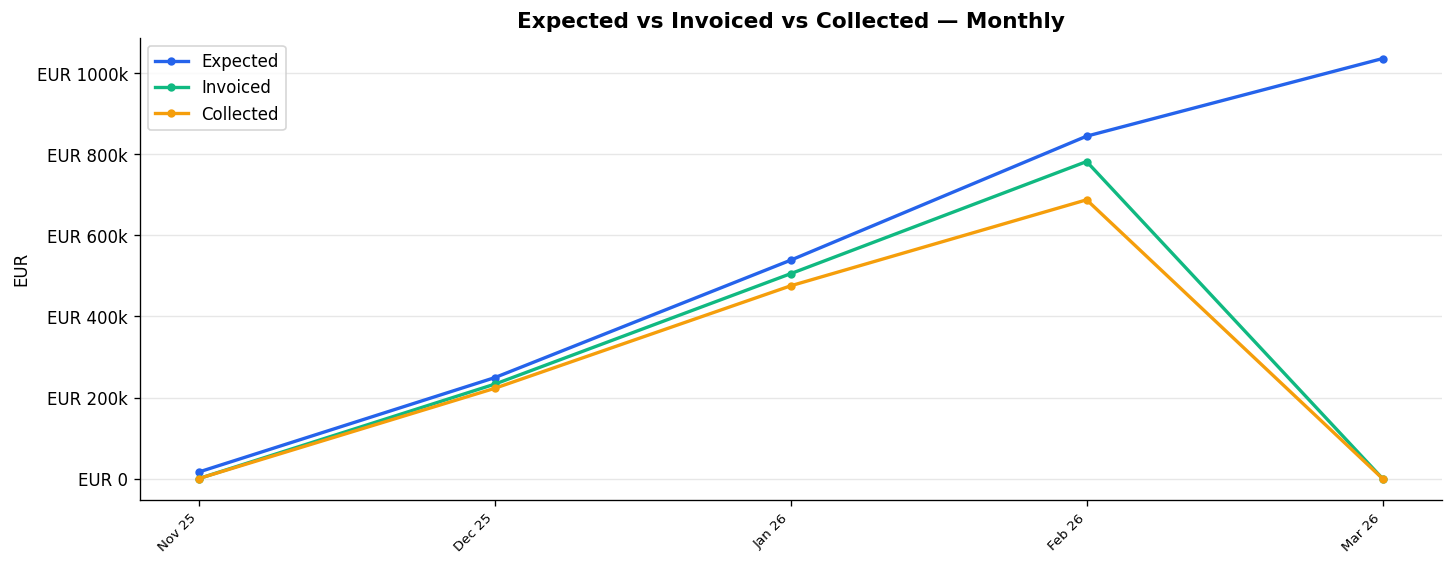

  Saved: /content/outputs/charts/F1_monthly_billing_waterfall.png


In [15]:
# ── F1. Expected vs Invoiced vs Collected by Month ───────────────────────────
print('F1 — Monthly Billing Waterfall')

if not kpi_monthly.empty:
    cols_map = {'expected_eur': ('Expected', PALETTE[0]),
                'invoiced_eur': ('Invoiced', PALETTE[1]),
                'collected_eur': ('Collected', PALETTE[2])}
    present = [(c, lbl, clr) for c, (lbl, clr) in cols_map.items() if c in kpi_monthly.columns]
    if present:
        fig, ax = plt.subplots(figsize=(14, 5))
        x = range(len(kpi_monthly))
        for col, lbl, clr in present:
            ax.plot(x, kpi_monthly[col], marker='o', markersize=4,
                    label=lbl, color=clr, linewidth=2)
        ax.set_xticks(list(x))
        ax.set_xticklabels(
            kpi_monthly['invoice_month'].dt.strftime('%b %y').tolist(),
            rotation=45, ha='right', fontsize=8)
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_eur))
        ax.legend()
        ax.set_title('Expected vs Invoiced vs Collected — Monthly', fontsize=13, fontweight='bold')
        ax.set_ylabel('EUR')
        ax.grid(axis='y', alpha=0.3)
        save_chart(fig, 'F1_monthly_billing_waterfall')


F2 — Exceptions by Type


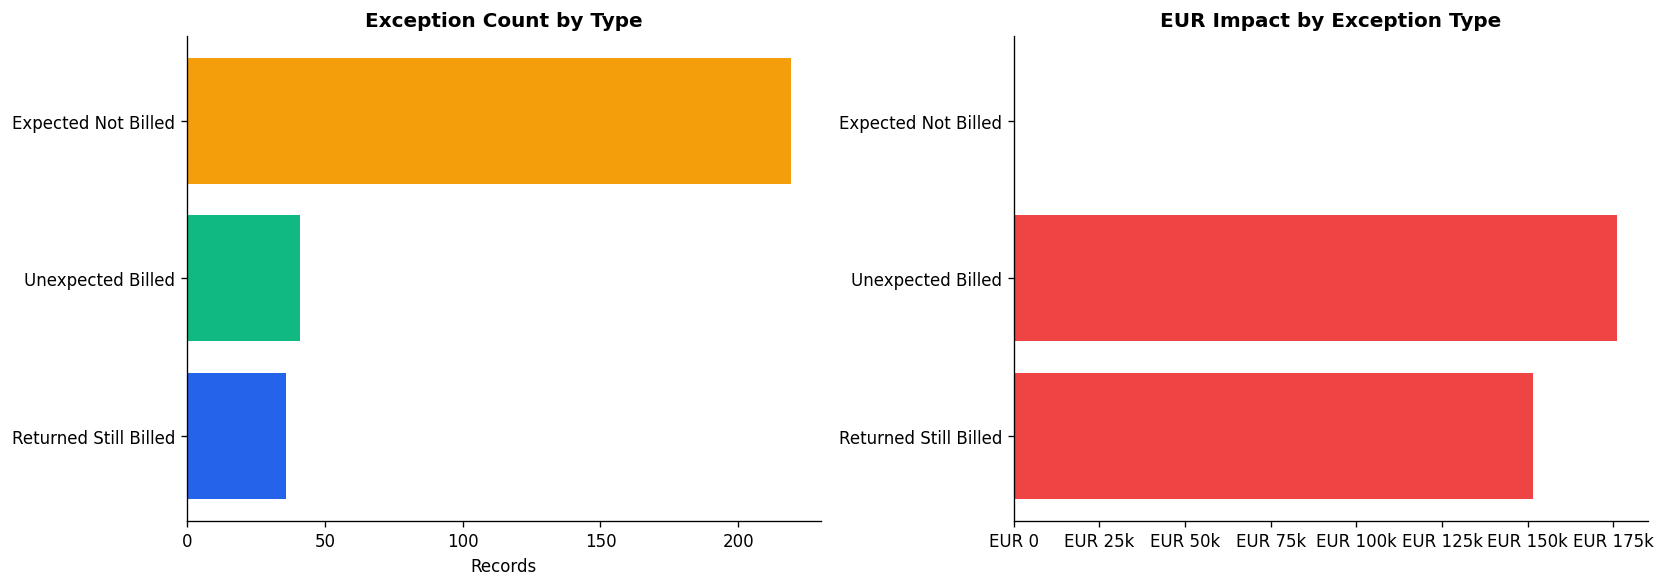

  Saved: /content/outputs/charts/F2_exceptions_by_type.png


In [16]:
# ── F2. Exceptions by Type ───────────────────────────────────────────────────
print('F2 — Exceptions by Type')

if not exc_summary.empty and exc_summary['record_count'].sum() > 0:
    df_plot = exc_summary[exc_summary['record_count'] > 0].sort_values('record_count', ascending=True)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].barh(df_plot['exception_type'], df_plot['record_count'], color=PALETTE[:len(df_plot)])
    axes[0].set_title('Exception Count by Type', fontweight='bold')
    axes[0].set_xlabel('Records')
    if 'eur_impact' in df_plot.columns:
        axes[1].barh(df_plot['exception_type'], df_plot['eur_impact'], color=PALETTE[3])
        axes[1].set_title('EUR Impact by Exception Type', fontweight='bold')
        axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(fmt_eur))
    plt.tight_layout()
    save_chart(fig, 'F2_exceptions_by_type')
else:
    print('  No exceptions to chart')


F3 — Complaint Rate by Segment


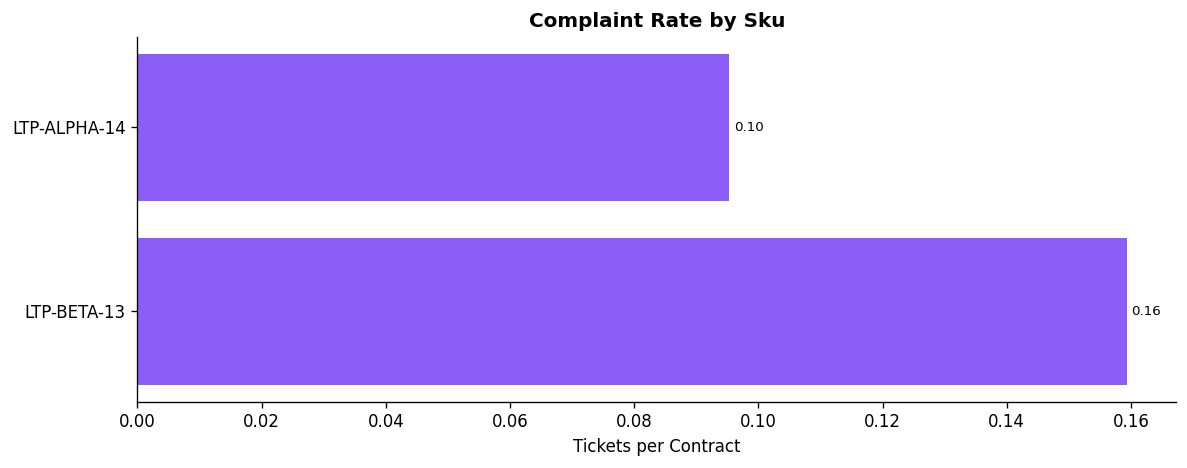

  Saved: /content/outputs/charts/F3_complaint_rate_sku.png


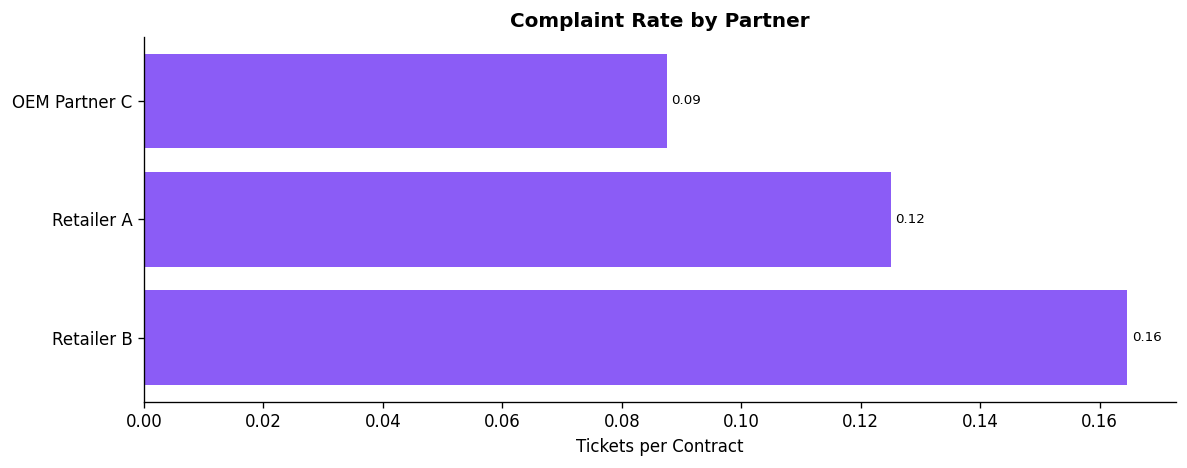

  Saved: /content/outputs/charts/F3_complaint_rate_partner.png


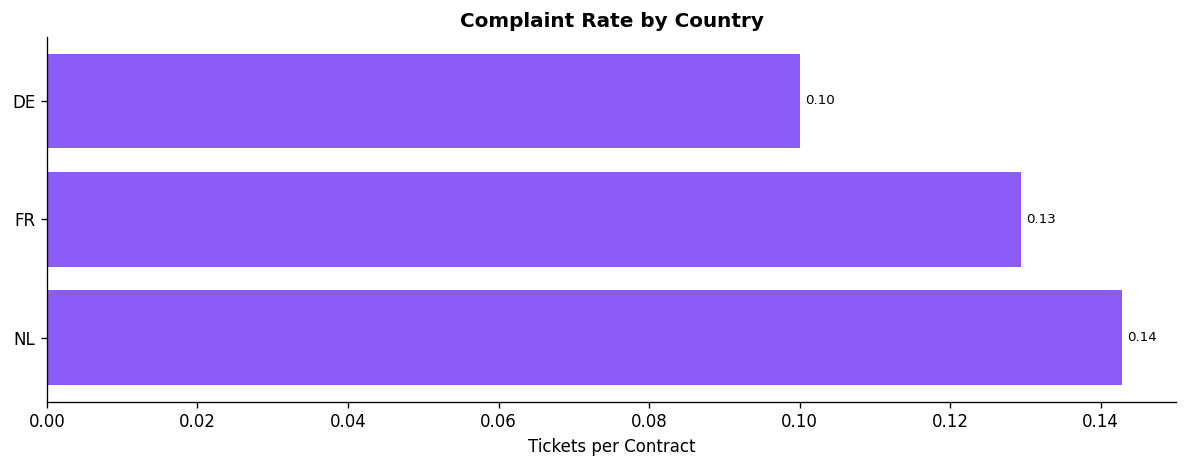

  Saved: /content/outputs/charts/F3_complaint_rate_country.png


In [17]:
# ── F3. Complaint Rate by Segment ────────────────────────────────────────────
print('F3 — Complaint Rate by Segment')

for dim, kdf in kpi_segments.items():
    if 'complaint_rate' in kdf.columns and kdf['complaint_rate'].notna().any():
        df_plot = kdf.dropna(subset=['complaint_rate']).sort_values(
            'complaint_rate', ascending=False).head(15)
        fig, ax = plt.subplots(figsize=(10, max(4, len(df_plot) * 0.45)))
        bars = ax.barh(df_plot[dim].astype(str), df_plot['complaint_rate'], color=PALETTE[4])
        ax.set_title(f'Complaint Rate by {dim.title()}', fontweight='bold')
        ax.set_xlabel('Tickets per Contract')
        ax.bar_label(bars, fmt='%.2f', padding=3, fontsize=8)
        plt.tight_layout()
        save_chart(fig, f'F3_complaint_rate_{dim}')


F4 — Pareto of Issue Categories


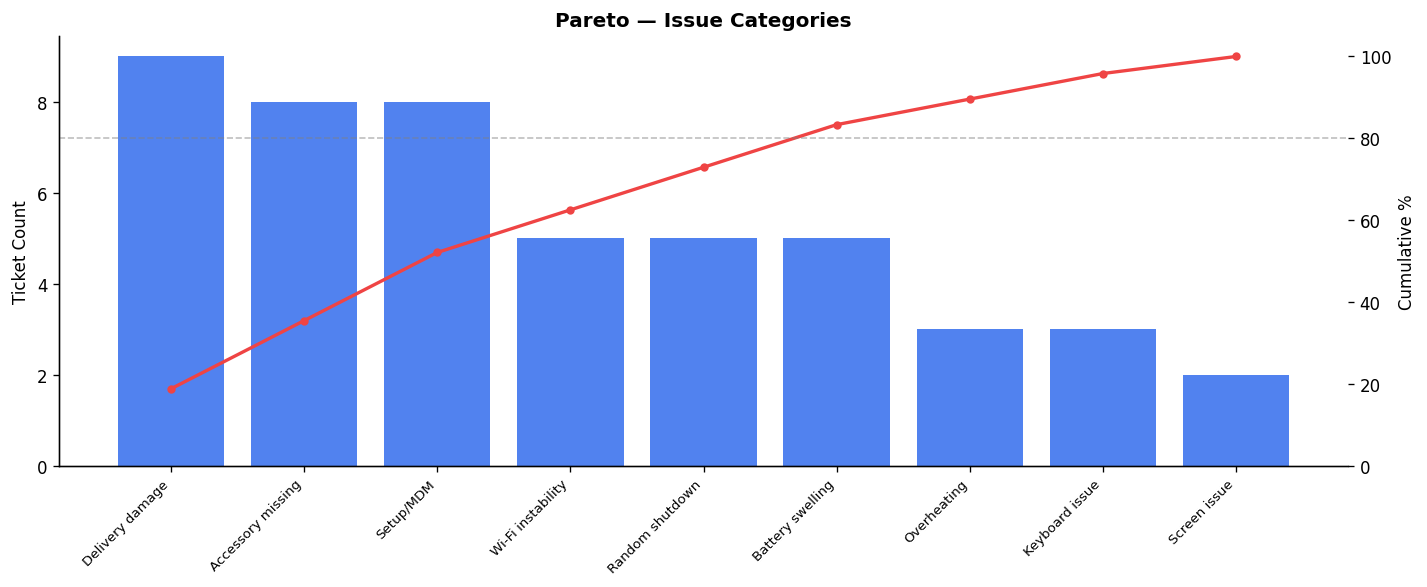

  Saved: /content/outputs/charts/F4_pareto_issue_categories.png


In [18]:
# ── F4. Pareto of Issue Categories ───────────────────────────────────────────
print('F4 — Pareto of Issue Categories')

if not tickets.empty and 'issue_category' in tickets.columns:
    cat_counts = tickets['issue_category'].value_counts().reset_index()
    cat_counts.columns = ['issue_category', 'count']
    cat_counts = cat_counts.head(20)
    cat_counts['cum_pct'] = cat_counts['count'].cumsum() / cat_counts['count'].sum() * 100
    fig, ax1 = plt.subplots(figsize=(12, 5))
    ax2 = ax1.twinx()
    ax1.bar(range(len(cat_counts)), cat_counts['count'], color=PALETTE[0], alpha=0.8)
    ax2.plot(range(len(cat_counts)), cat_counts['cum_pct'],
             color=PALETTE[3], marker='o', markersize=4, linewidth=2)
    ax2.axhline(80, color='grey', linestyle='--', alpha=0.5, linewidth=1)
    ax2.set_ylabel('Cumulative %')
    ax2.set_ylim(0, 105)
    ax1.set_xticks(range(len(cat_counts)))
    ax1.set_xticklabels(cat_counts['issue_category'], rotation=45, ha='right', fontsize=8)
    ax1.set_ylabel('Ticket Count')
    ax1.set_title('Pareto — Issue Categories', fontweight='bold')
    plt.tight_layout()
    save_chart(fig, 'F4_pareto_issue_categories')
else:
    print('  No issue_category column found in tickets')


F5 — DPD Distribution


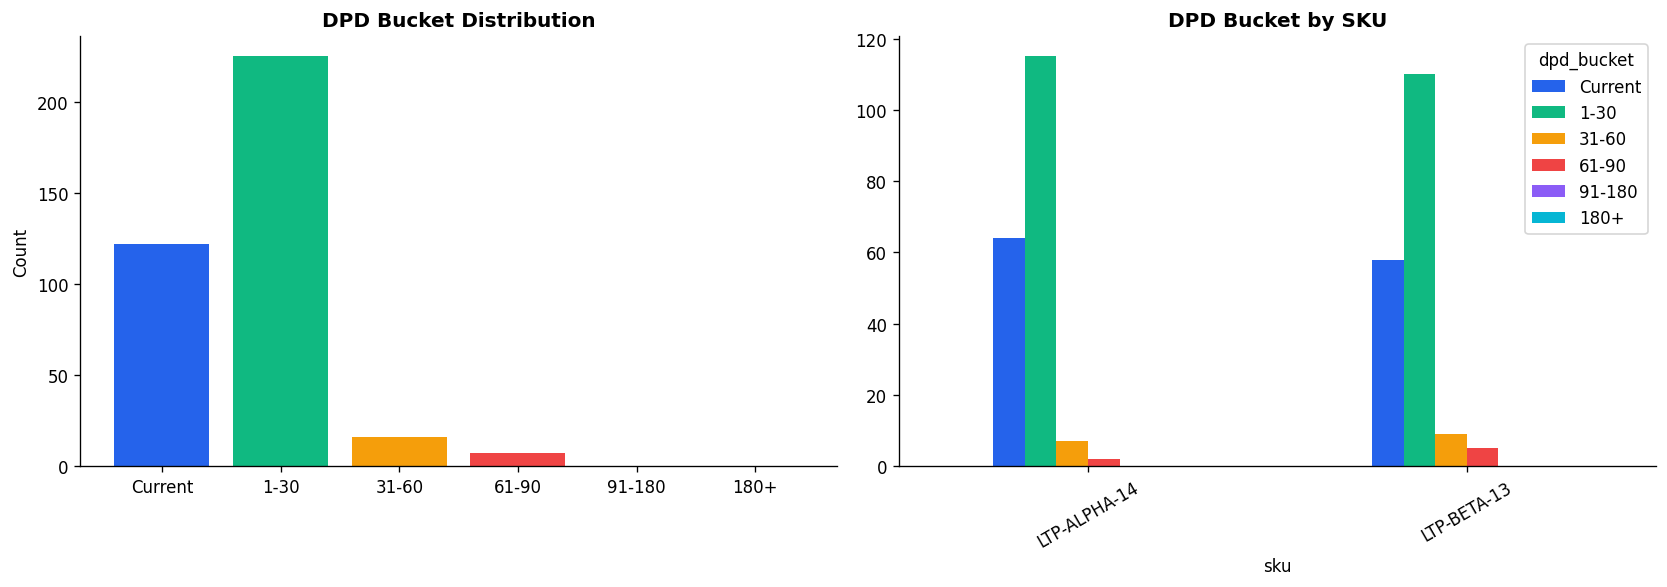

  Saved: /content/outputs/charts/F5_dpd_distribution.png


In [19]:
# ── F5. DPD Distribution ─────────────────────────────────────────────────────
print('F5 — DPD Distribution')

if 'dpd' in exc.columns and exc['dpd'].notna().any():
    exc['dpd_bucket'] = pd.cut(
        exc['dpd'].clip(lower=0),
        bins=[-1, 0, 30, 60, 90, 180, float('inf')],
        labels=['Current', '1-30', '31-60', '61-90', '91-180', '180+'])
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    dpd_overall = exc['dpd_bucket'].value_counts().sort_index()
    axes[0].bar(dpd_overall.index.astype(str), dpd_overall.values,
                color=PALETTE[:len(dpd_overall)])
    axes[0].set_title('DPD Bucket Distribution', fontweight='bold')
    axes[0].set_ylabel('Count')
    if 'sku' in exc.columns:
        dpd_by_sku = exc.groupby(['sku', 'dpd_bucket']).size().unstack(fill_value=0)
        dpd_by_sku.plot(kind='bar', ax=axes[1],
                        color=PALETTE[:len(dpd_by_sku.columns)], rot=30)
        axes[1].set_title('DPD Bucket by SKU', fontweight='bold')
    plt.tight_layout()
    save_chart(fig, 'F5_dpd_distribution')
else:
    print('  DPD column not available')


F6 — Repair/Swap by Segment


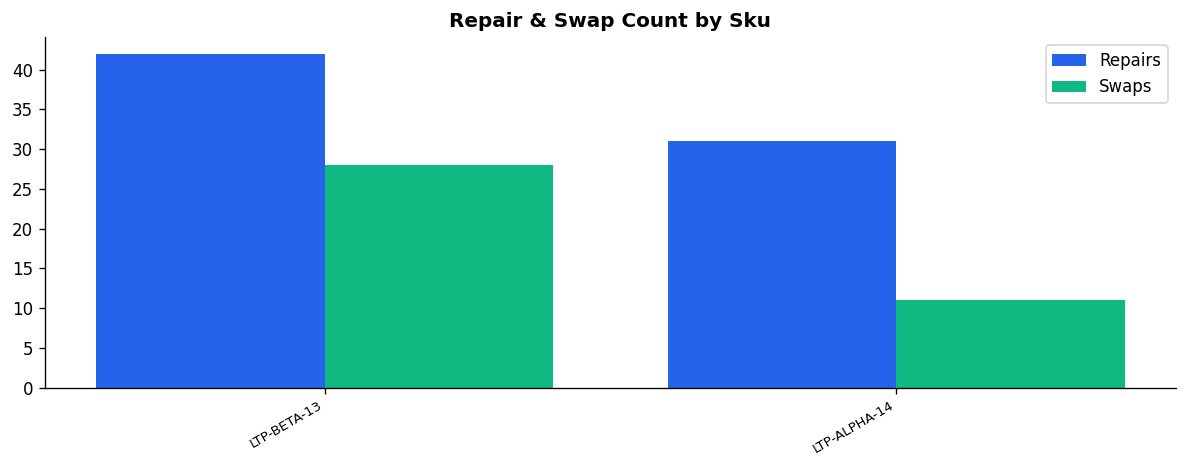

  Saved: /content/outputs/charts/F6_repair_swap_sku.png


In [20]:
# ── F6. Repair/Swap Rate by Segment ─────────────────────────────────────────
print('F6 — Repair/Swap by Segment')

for dim in ['sku', 'partner', 'country']:
    if dim in exc.columns and 'repair_count' in exc.columns:
        rs = exc.groupby(dim).agg(
            repair_count=('repair_count', 'sum'),
            swap_count=('swap_count', 'sum') if 'swap_count' in exc.columns else ('repair_count', 'count'),
        ).reset_index().sort_values('repair_count', ascending=False).head(15)
        fig, ax = plt.subplots(figsize=(10, max(4, len(rs) * 0.45)))
        x = range(len(rs))
        ax.bar([i - 0.2 for i in x], rs['repair_count'], width=0.4, label='Repairs', color=PALETTE[0])
        ax.bar([i + 0.2 for i in x], rs['swap_count'],   width=0.4, label='Swaps',   color=PALETTE[1])
        ax.set_xticks(list(x))
        ax.set_xticklabels(rs[dim].astype(str), rotation=30, ha='right', fontsize=8)
        ax.legend()
        ax.set_title(f'Repair & Swap Count by {dim.title()}', fontweight='bold')
        plt.tight_layout()
        save_chart(fig, f'F6_repair_swap_{dim}')
        break


F7 — EUR Impact by Exception Type


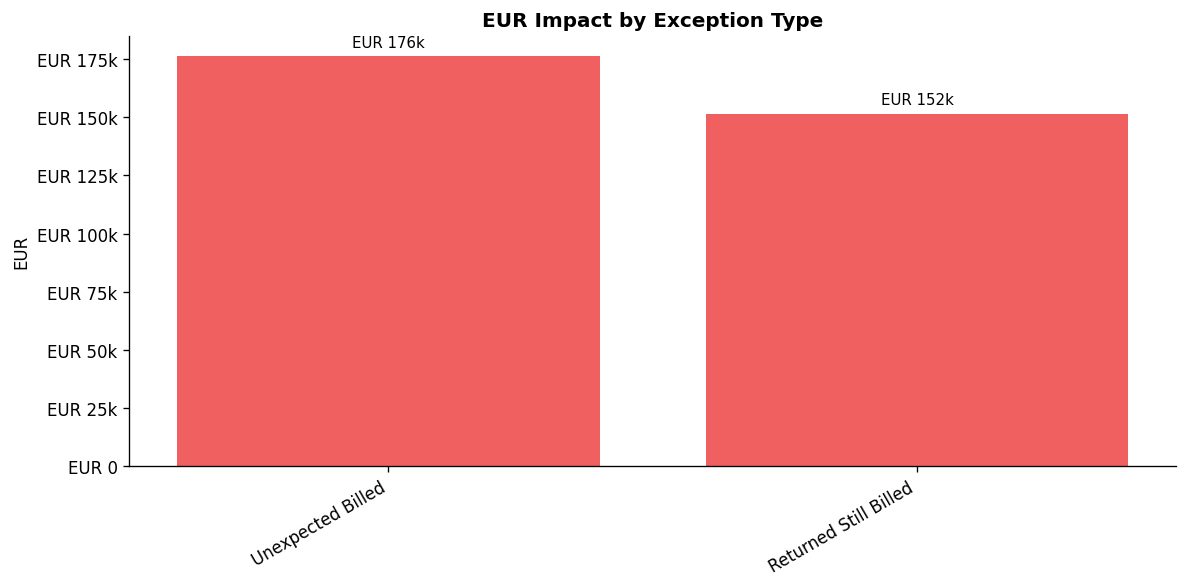

  Saved: /content/outputs/charts/F7_eur_impact_by_exception.png


In [21]:
# ── F7. EUR Impact by Exception Type ────────────────────────────────────────
print('F7 — EUR Impact by Exception Type')

if not exc_summary.empty and exc_summary.get('eur_impact', pd.Series([0])).sum() > 0:
    df_plot = exc_summary[exc_summary['eur_impact'] > 0].sort_values('eur_impact', ascending=False)
    fig, ax = plt.subplots(figsize=(10, 5))
    bars = ax.bar(df_plot['exception_type'], df_plot['eur_impact'],
                  color=PALETTE[3], alpha=0.85)
    ax.set_title('EUR Impact by Exception Type', fontweight='bold')
    ax.set_ylabel('EUR')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_eur))
    ax.set_xticklabels(df_plot['exception_type'], rotation=30, ha='right')
    ax.bar_label(bars, labels=[fmt_eur(v, None) for v in df_plot['eur_impact']],
                 padding=4, fontsize=9)
    plt.tight_layout()
    save_chart(fig, 'F7_eur_impact_by_exception')
else:
    print('  No EUR impact data to chart')


---
## G. Executive Summary (Storytelling)

In [22]:
# ── G. EXEC SUMMARY ──────────────────────────────────────────────────────────

def safe_sum(df, col):
    return float(df[col].sum()) if col in df.columns else 0.0
def safe_mean(df, col):
    return float(df[col].mean()) if col in df.columns and df[col].notna().any() else 0.0

total_expected  = safe_sum(exc, 'monthly_price_eur')
total_invoiced  = safe_sum(exc, 'billed_amount_eur')
total_collected = safe_sum(exc, 'collected_amount_eur')
total_exceptions = int(exc.get('any_exception', pd.Series(False)).sum())
exception_pct   = total_exceptions / max(len(exc), 1) * 100
avg_dpd         = safe_mean(exc, 'dpd')
leakage         = total_expected - total_collected
bill_cov        = total_invoiced / max(total_expected, 1) * 100
coll_rate       = total_collected / max(total_invoiced, 1) * 100

lines = [
    '# Executive Summary — Topi FinOps Analytics\n',
    f'**Generated:** {datetime.now().strftime("%Y-%m-%d %H:%M")}  \n',
    '**Analyst:** Automated Pipeline v1.0  \n\n',
    '---\n',
    '## 1. Financial Snapshot\n',
    '| Metric | Value |\n',
    '|--------|-------|\n',
    f'| Expected Revenue (contract MRR) | EUR {total_expected:,.0f} |\n',
    f'| Invoiced Revenue | EUR {total_invoiced:,.0f} |\n',
    f'| Collected Revenue | EUR {total_collected:,.0f} |\n',
    f'| Revenue Leakage (Expected minus Collected) | EUR {leakage:,.0f} |\n',
    f'| Billing Coverage | {bill_cov:.1f}% |\n',
    f'| Collection Rate | {coll_rate:.1f}% |\n',
    '\n---\n',
    '## 2. Operational Snapshot\n',
    '| Metric | Value |\n',
    '|--------|-------|\n',
    f'| Total DCB rows | {len(exc):,} |\n',
    f'| Average DPD | {avg_dpd:.1f} days |\n',
    f'| Reconciliation Exceptions | {total_exceptions:,} ({exception_pct:.1f}%) |\n',
    '\n---\n',
    '## 3. Top Risks\n',
    f'1. **Revenue Leakage of EUR {leakage:,.0f}** — gap between contracted MRR and collected.\n',
    f'2. **{exception_pct:.1f}% Exception Rate** — signals systemic billing or status-sync issues.\n',
    f'3. **Average DPD of {avg_dpd:.1f} days** — late payment trend.\n',
    '4. **High complaint concentration** — Pareto shows top issues drive majority of tickets.\n',
    '\n---\n',
    '## 4. Recommended Actions\n',
    '| Priority | Action | Owner |\n',
    '|----------|--------|-------|\n',
    '| HIGH | Resolve Expected-Not-Billed exceptions — recover unbilled MRR | Finance/Ops |\n',
    '| HIGH | Investigate Paused-But-Billed — refund or correct to avoid churn | Billing Team |\n',
    '| MED  | DPD remediation campaign for 60+ day overdue invoices | Collections |\n',
    '| MED  | Root-cause top 3 complaint categories; create resolution playbook | Support |\n',
    '| LOW  | Add device return webhook to billing system | Platform |\n',
    '\n---\n',
    '## 5. Next Data to Collect\n',
    '- Return/RMA timestamps linked to billing stop dates.\n',
    '- Customer segment tags (SME, Enterprise, Consumer) for cohort analysis.\n',
    '- Cost-to-serve per ticket from CRM/helpdesk for full P&L view.\n',
    '- Device health telemetry (failure rates, MTBF) to predict repair/swap volumes.\n',
    '- Contract renewal signals (upcoming contract_end within 90 days).\n',
    '\n---\n',
    '*Auto-generated. Validate with source data before distribution.*\n',
]

(DOCS / 'EXEC_SUMMARY.md').write_text(''.join(lines))
print('✅ EXEC_SUMMARY.md written')
print(''.join(lines[:20]))


✅ EXEC_SUMMARY.md written
# Executive Summary — Topi FinOps Analytics
**Generated:** 2026-03-01 16:06  
**Analyst:** Automated Pipeline v1.0  

---
## 1. Financial Snapshot
| Metric | Value |
|--------|-------|
| Expected Revenue (contract MRR) | EUR 2,685,722 |
| Invoiced Revenue | EUR 1,521,018 |
| Collected Revenue | EUR 1,386,368 |
| Revenue Leakage (Expected minus Collected) | EUR 1,299,354 |
| Billing Coverage | 56.6% |
| Collection Rate | 91.1% |

---
## 2. Operational Snapshot
| Metric | Value |
|--------|-------|
| Total DCB rows | 601 |
| Average DPD | 5.4 days |
| Reconciliation Exceptions | 260 (43.3%) |



---
## H. Segment Scorecard

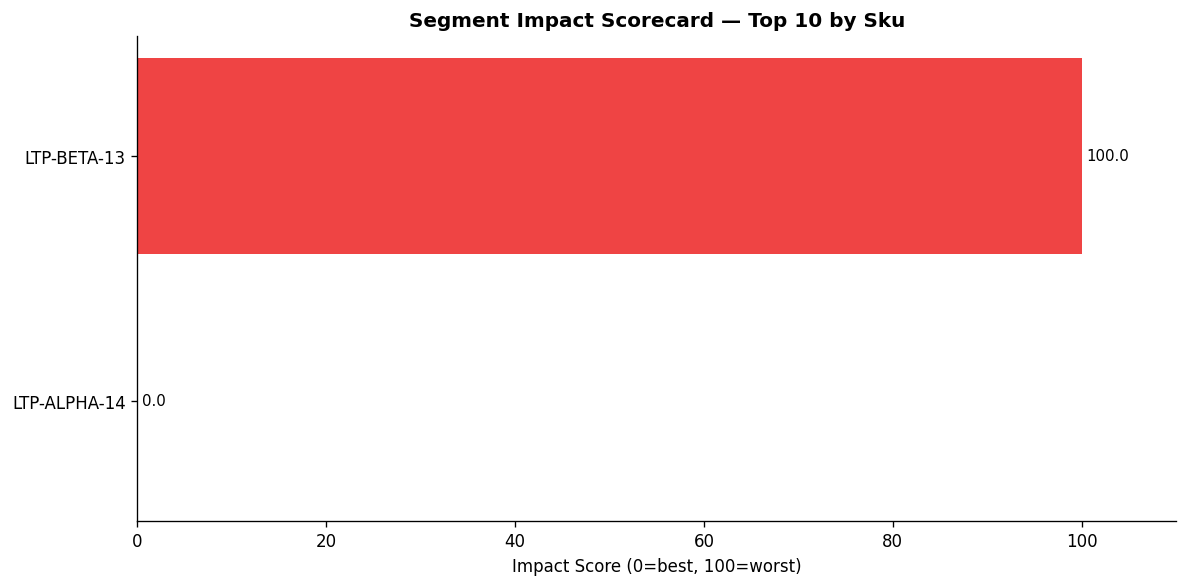

  Saved: /content/outputs/charts/H_segment_scorecard_top10.png
✅ segment_scorecard.csv written


,sku,contract_count,total_tickets,total_exceptions,avg_dpd,total_repairs,total_swaps,invoiced_eur,collected_eur,complaint_rate,exception_rate,repair_swap_rate,collection_rate_pct,impact_score,rank
0,LTP-BETA-13,113,18.00,124,6.29,42,28,"674,202.00","601,038.00",0.16,1.10,0.62,89.15,100.00,1
1,LTP-ALPHA-14,126,12.00,136,4.45,31,11,"846,816.00","785,330.00",0.10,1.08,0.33,92.74,0.00,2


In [23]:
# ── H. SEGMENT SCORECARD ─────────────────────────────────────────────────────
# Editable weights (must sum to 1.0)
SCORECARD_WEIGHTS = {
    'complaint_rate':      0.25,
    'exception_rate':      0.25,
    'avg_dpd':             0.20,
    'repair_swap_rate':    0.15,
    'collection_rate_pct': 0.15,  # higher is better — inverted in scoring
}

SEGMENT_DIM = 'sku'  # change to 'partner' or 'country' as needed

if SEGMENT_DIM in exc.columns:
    cnt_col = 'contract_id' if 'contract_id' in exc.columns else exc.columns[0]
    sc_agg = exc.groupby(SEGMENT_DIM).agg(
        contract_count  =(cnt_col, 'nunique'),
        total_tickets   =('ticket_count', 'sum')   if 'ticket_count' in exc.columns   else (cnt_col, 'count'),
        total_exceptions=('any_exception', 'sum'),
        avg_dpd         =('dpd', 'mean')            if 'dpd' in exc.columns            else (cnt_col, 'count'),
        total_repairs   =('repair_count', 'sum')   if 'repair_count' in exc.columns   else (cnt_col, 'count'),
        total_swaps     =('swap_count', 'sum')     if 'swap_count' in exc.columns     else (cnt_col, 'count'),
        invoiced_eur    =('billed_amount_eur', 'sum')    if 'billed_amount_eur' in exc.columns    else (cnt_col, 'count'),
        collected_eur   =('collected_amount_eur', 'sum') if 'collected_amount_eur' in exc.columns else (cnt_col, 'count'),
    ).reset_index()

    sc_agg['complaint_rate']    = sc_agg['total_tickets']   / sc_agg['contract_count'].replace(0, np.nan)
    sc_agg['exception_rate']    = sc_agg['total_exceptions']/ sc_agg['contract_count'].replace(0, np.nan)
    sc_agg['repair_swap_rate']  = (sc_agg['total_repairs'] + sc_agg['total_swaps']) / sc_agg['contract_count'].replace(0, np.nan)
    sc_agg['collection_rate_pct'] = sc_agg['collected_eur'] / sc_agg['invoiced_eur'].replace(0, np.nan) * 100
    sc_agg['avg_dpd']           = sc_agg['avg_dpd'].fillna(0)

    def minmax_norm(series):
        mn, mx = series.min(), series.max()
        if mx == mn:
            return pd.Series(50, index=series.index)
        return (series - mn) / (mx - mn) * 100

    METRICS = [
        ('complaint_rate',      True),
        ('exception_rate',      True),
        ('avg_dpd',             True),
        ('repair_swap_rate',    True),
        ('collection_rate_pct', False),  # higher = better, so invert
    ]

    sc_agg['impact_score'] = 0.0
    total_w = 0
    for col, higher_is_worse in METRICS:
        if col not in sc_agg.columns:
            continue
        norm = minmax_norm(sc_agg[col].fillna(0))
        if not higher_is_worse:
            norm = 100 - norm
        w = SCORECARD_WEIGHTS.get(col, 0)
        sc_agg['impact_score'] += norm * w
        total_w += w
    if total_w > 0:
        sc_agg['impact_score'] = sc_agg['impact_score'] / total_w

    sc_agg = sc_agg.sort_values('impact_score', ascending=False).reset_index(drop=True)
    sc_agg['rank'] = sc_agg.index + 1
    sc_agg.to_csv(OUT / 'segment_scorecard.csv', index=False)

    top10 = sc_agg.head(10)
    colors_sc = [PALETTE[3] if v >= 70 else PALETTE[2] if v >= 40 else PALETTE[1]
                 for v in top10['impact_score']]
    fig, ax = plt.subplots(figsize=(10, 5))
    bars = ax.barh(top10[SEGMENT_DIM].astype(str)[::-1],
                   top10['impact_score'].values[::-1], color=colors_sc[::-1])
    ax.set_title(f'Segment Impact Scorecard — Top 10 by {SEGMENT_DIM.title()}', fontweight='bold')
    ax.set_xlabel('Impact Score (0=best, 100=worst)')
    ax.bar_label(bars, fmt='%.1f', padding=3, fontsize=9)
    ax.set_xlim(0, 110)
    plt.tight_layout()
    save_chart(fig, 'H_segment_scorecard_top10')

    print('✅ segment_scorecard.csv written')
    display(sc_agg.head(10))
else:
    sc_agg = pd.DataFrame()
    print(f'Segment dim "{SEGMENT_DIM}" not in DCB — scorecard skipped')


---
## I. Early Warning System

In [24]:
# ── I. EARLY WARNING SYSTEM ──────────────────────────────────────────────────
# Editable thresholds
EW_THRESHOLDS = {
    'complaint_rate_red':    2.0,
    'complaint_rate_amber':  1.0,
    'exception_rate_red':    0.15,
    'exception_rate_amber':  0.05,
    'dpd_red':               90,
    'dpd_amber':             30,
    'collection_rate_red':   0.80,
    'collection_rate_amber': 0.90,
    'repair_swap_rate_red':  0.30,
    'repair_swap_rate_amber':0.10,
}

def traffic_light(val, red_t, amber_t, higher_is_worse=True):
    if pd.isna(val): return 'N/A'
    if higher_is_worse:
        return 'RED' if val >= red_t else ('AMBER' if val >= amber_t else 'GREEN')
    return 'RED' if val <= red_t else ('AMBER' if val <= amber_t else 'GREEN')

EMOJI = {'RED': '🔴 RED', 'AMBER': '🟡 AMBER', 'GREEN': '🟢 GREEN', 'N/A': '⚪ N/A'}

if not sc_agg.empty and SEGMENT_DIM in sc_agg.columns:
    ew_cols_needed = ['complaint_rate', 'exception_rate', 'avg_dpd',
                      'collection_rate_pct', 'repair_swap_rate']
    ew_df = sc_agg[[c for c in [SEGMENT_DIM] + ew_cols_needed if c in sc_agg.columns]].copy()
    ew_df['coll_dec'] = ew_df.get('collection_rate_pct', pd.Series(100)) / 100

    ew_df['ew_complaint']   = ew_df.get('complaint_rate',   pd.Series(0)).apply(
        lambda v: EMOJI[traffic_light(v, EW_THRESHOLDS['complaint_rate_red'], EW_THRESHOLDS['complaint_rate_amber'])])
    ew_df['ew_exception']   = ew_df.get('exception_rate',   pd.Series(0)).apply(
        lambda v: EMOJI[traffic_light(v, EW_THRESHOLDS['exception_rate_red'], EW_THRESHOLDS['exception_rate_amber'])])
    ew_df['ew_dpd']         = ew_df.get('avg_dpd',          pd.Series(0)).apply(
        lambda v: EMOJI[traffic_light(v, EW_THRESHOLDS['dpd_red'], EW_THRESHOLDS['dpd_amber'])])
    ew_df['ew_collection']  = ew_df['coll_dec'].apply(
        lambda v: EMOJI[traffic_light(v, EW_THRESHOLDS['collection_rate_red'],
                                         EW_THRESHOLDS['collection_rate_amber'], higher_is_worse=False)])
    ew_df['ew_repair_swap'] = ew_df.get('repair_swap_rate', pd.Series(0)).apply(
        lambda v: EMOJI[traffic_light(v, EW_THRESHOLDS['repair_swap_rate_red'], EW_THRESHOLDS['repair_swap_rate_amber'])])

    ew_flag_cols = [c for c in ew_df.columns if c.startswith('ew_')]
    def overall_status(row):
        vals = [str(row[c]) for c in ew_flag_cols]
        if any('RED' in v for v in vals): return '🔴 RED'
        if any('AMBER' in v for v in vals): return '🟡 AMBER'
        return '🟢 GREEN'
    ew_df['overall_status'] = ew_df.apply(overall_status, axis=1)

    ew_df.to_csv(OUT / 'early_warning_flags.csv', index=False)
    print('✅ early_warning_flags.csv written')
    display(ew_df[[SEGMENT_DIM] + ew_flag_cols + ['overall_status']].head(15))
else:
    ew_df = pd.DataFrame()
    print('No scorecard data — run Section H first')

# Write rules doc
ew_lines = [
    '# Early Warning System — Rules and Thresholds\n',
    f'**Generated:** {datetime.now().strftime("%Y-%m-%d %H:%M")}\n\n',
    '## Threshold Definitions\n',
    '| KPI | RED | AMBER | GREEN |\n',
    '|-----|-----|-------|-------|\n',
    f'| Complaint Rate | >= {EW_THRESHOLDS["complaint_rate_red"]} | >= {EW_THRESHOLDS["complaint_rate_amber"]} | < {EW_THRESHOLDS["complaint_rate_amber"]} |\n',
    f'| Exception Rate | >= {EW_THRESHOLDS["exception_rate_red"]*100:.0f}% | >= {EW_THRESHOLDS["exception_rate_amber"]*100:.0f}% | < {EW_THRESHOLDS["exception_rate_amber"]*100:.0f}% |\n',
    f'| Avg DPD | >= {EW_THRESHOLDS["dpd_red"]} | >= {EW_THRESHOLDS["dpd_amber"]} | < {EW_THRESHOLDS["dpd_amber"]} |\n',
    f'| Collection Rate | < {EW_THRESHOLDS["collection_rate_red"]*100:.0f}% | < {EW_THRESHOLDS["collection_rate_amber"]*100:.0f}% | >= {EW_THRESHOLDS["collection_rate_amber"]*100:.0f}% |\n',
    f'| Repair/Swap Rate | >= {EW_THRESHOLDS["repair_swap_rate_red"]*100:.0f}% | >= {EW_THRESHOLDS["repair_swap_rate_amber"]*100:.0f}% | < {EW_THRESHOLDS["repair_swap_rate_amber"]*100:.0f}% |\n',
    '\n## How to Edit Thresholds\n',
    'Edit the EW_THRESHOLDS dictionary in Section I and re-run.\n',
    '\n## Overall Status Logic\n',
    '- RED = any individual KPI is RED\n',
    '- AMBER = no RED, but at least one KPI is AMBER\n',
    '- GREEN = all KPIs green\n',
]
(DOCS / 'EARLY_WARNING_RULES.md').write_text(''.join(ew_lines))
print('✅ EARLY_WARNING_RULES.md written')


✅ early_warning_flags.csv written


,sku,ew_complaint,ew_exception,ew_dpd,ew_collection,ew_repair_swap,overall_status
0,LTP-BETA-13,🟢 GREEN,🔴 RED,🟢 GREEN,🟡 AMBER,🔴 RED,🔴 RED
1,LTP-ALPHA-14,🟢 GREEN,🔴 RED,🟢 GREEN,🟢 GREEN,🔴 RED,🔴 RED


✅ EARLY_WARNING_RULES.md written


---
## J. Financial Impact Model

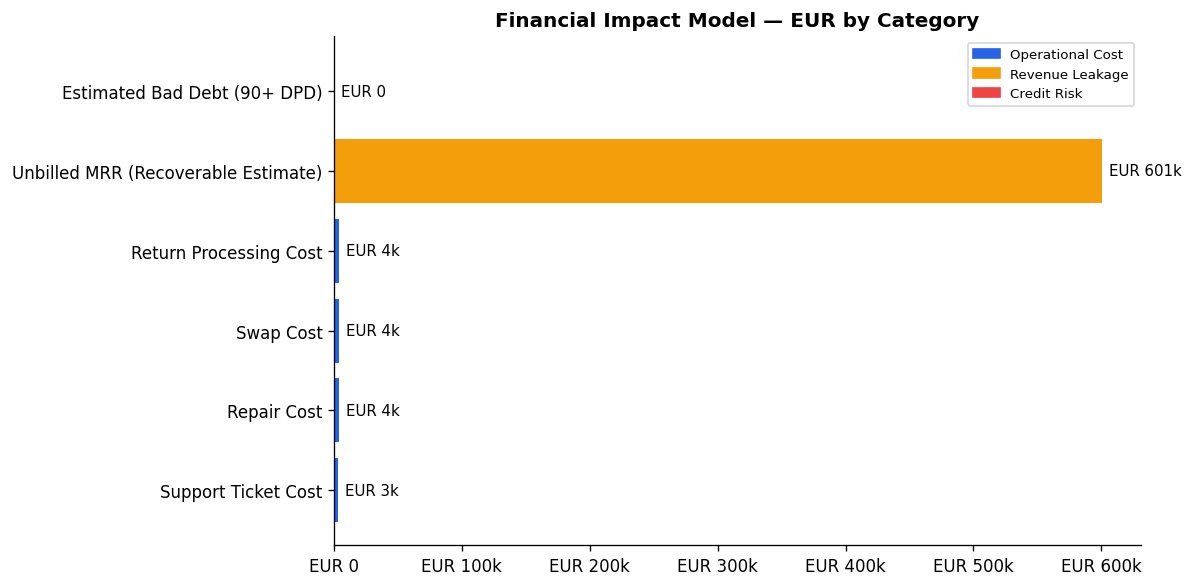

  Saved: /content/outputs/charts/J_financial_impact_model.png

✅ Financial Impact Model complete


,category,driver,eur_impact,type
0,Support Ticket Cost,48 tickets,"3,245.00",Operational Cost
1,Repair Cost,32 events,"3,840.00",Operational Cost
2,Swap Cost,15 events,"3,750.00",Operational Cost
3,Return Processing Cost,52 events,"4,160.00",Operational Cost
4,Unbilled MRR (Recoverable Estimate),"EUR 1,001,514 gross unbilled","600,908.40",Revenue Leakage
5,Estimated Bad Debt (90+ DPD),EUR 0 overdue,0.00,Credit Risk


TOTAL ESTIMATED IMPACT: EUR 615,903


In [25]:
# ── J. FINANCIAL IMPACT MODEL ────────────────────────────────────────────────
# Editable assumptions
FIN_ASSUMPTIONS = {
    'cost_per_ticket_low_eur':       25,
    'cost_per_ticket_medium_eur':    60,
    'cost_per_ticket_high_eur':     150,
    'cost_per_ticket_critical_eur': 300,
    'cost_per_ticket_default_eur':   50,
    'cost_per_repair_eur':          120,
    'cost_per_swap_eur':            250,
    'cost_per_return_eur':           80,
    'leakage_recovery_rate':         0.60,
    'bad_debt_rate_on_overdue':      0.30,
}

impact_rows = []

# 1. Support ticket cost
if not tickets.empty:
    def ticket_cost(sev):
        s = str(sev).lower()
        if any(x in s for x in ['critical', 'p1']): return FIN_ASSUMPTIONS['cost_per_ticket_critical_eur']
        if any(x in s for x in ['high', 'p2']):     return FIN_ASSUMPTIONS['cost_per_ticket_high_eur']
        if any(x in s for x in ['medium', 'p3']):   return FIN_ASSUMPTIONS['cost_per_ticket_medium_eur']
        if any(x in s for x in ['low', 'p4']):      return FIN_ASSUMPTIONS['cost_per_ticket_low_eur']
        return FIN_ASSUMPTIONS['cost_per_ticket_default_eur']
    tickets['_cost'] = tickets['severity'].apply(ticket_cost) if 'severity' in tickets.columns \
                       else FIN_ASSUMPTIONS['cost_per_ticket_default_eur']
    total_ticket_cost = tickets['_cost'].sum()
    impact_rows.append({'category': 'Support Ticket Cost',
                        'driver': f'{len(tickets):,} tickets',
                        'eur_impact': total_ticket_cost, 'type': 'Operational Cost'})

# 2. Lifecycle costs
if not lifecycle.empty and 'event_type' in lifecycle.columns:
    et = lifecycle['event_type'].str.lower()
    repairs = et.str.contains('repair|fix', na=False).sum()
    swaps   = et.str.contains('swap|replace|exchange', na=False).sum()
    returns = et.str.contains('return|rma', na=False).sum()
    for lbl, cnt, cost_key in [
        ('Repair Cost',             repairs, 'cost_per_repair_eur'),
        ('Swap Cost',               swaps,   'cost_per_swap_eur'),
        ('Return Processing Cost',  returns, 'cost_per_return_eur'),
    ]:
        impact_rows.append({'category': lbl, 'driver': f'{cnt:,} events',
                            'eur_impact': cnt * FIN_ASSUMPTIONS[cost_key],
                            'type': 'Operational Cost'})

# 3. Revenue leakage
if 'flag_expected_not_billed' in exc.columns and 'monthly_price_eur' in exc.columns:
    unbilled = exc.loc[exc['flag_expected_not_billed'], 'monthly_price_eur'].sum()
    recoverable = unbilled * FIN_ASSUMPTIONS['leakage_recovery_rate']
    impact_rows.append({'category': 'Unbilled MRR (Recoverable Estimate)',
                        'driver': f'EUR {unbilled:,.0f} gross unbilled',
                        'eur_impact': recoverable, 'type': 'Revenue Leakage'})

# 4. Bad debt
if 'dpd' in exc.columns and 'billed_amount_eur' in exc.columns:
    overdue_90 = exc.loc[exc['dpd'] >= 90, 'billed_amount_eur'].sum()
    bad_debt   = overdue_90 * FIN_ASSUMPTIONS['bad_debt_rate_on_overdue']
    impact_rows.append({'category': 'Estimated Bad Debt (90+ DPD)',
                        'driver': f'EUR {overdue_90:,.0f} overdue',
                        'eur_impact': bad_debt, 'type': 'Credit Risk'})

fim_df = pd.DataFrame(impact_rows)
fim_df.to_csv(OUT / 'financial_impact_model.csv', index=False)

if not fim_df.empty:
    from matplotlib.patches import Patch
    type_colors = {'Operational Cost': PALETTE[0], 'Revenue Leakage': PALETTE[2], 'Credit Risk': PALETTE[3]}
    bar_colors  = [type_colors.get(t, PALETTE[4]) for t in fim_df['type']]
    fig, ax = plt.subplots(figsize=(10, 5))
    bars = ax.barh(fim_df['category'], fim_df['eur_impact'], color=bar_colors)
    ax.set_title('Financial Impact Model — EUR by Category', fontweight='bold')
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(fmt_eur))
    ax.bar_label(bars, labels=[fmt_eur(v, None) for v in fim_df['eur_impact']], padding=4, fontsize=9)
    legend_els = [Patch(color=c, label=t) for t, c in type_colors.items()]
    ax.legend(handles=legend_els, fontsize=8)
    plt.tight_layout()
    save_chart(fig, 'J_financial_impact_model')

print('\n✅ Financial Impact Model complete')
display(fim_df)
print(f'TOTAL ESTIMATED IMPACT: EUR {fim_df["eur_impact"].sum():,.0f}')


In [26]:
# ── J2. Financial Impact Assumptions Markdown ────────────────────────────────
fa_lines = [
    '# Financial Impact Model — Assumptions\n',
    f'**Generated:** {datetime.now().strftime("%Y-%m-%d %H:%M")}\n\n',
    '## Cost Assumptions\n',
    '| Parameter | Value (EUR) |\n',
    '|-----------|-------------|\n',
    f'| Cost per ticket — Low | EUR {FIN_ASSUMPTIONS["cost_per_ticket_low_eur"]} |\n',
    f'| Cost per ticket — Medium | EUR {FIN_ASSUMPTIONS["cost_per_ticket_medium_eur"]} |\n',
    f'| Cost per ticket — High | EUR {FIN_ASSUMPTIONS["cost_per_ticket_high_eur"]} |\n',
    f'| Cost per ticket — Critical | EUR {FIN_ASSUMPTIONS["cost_per_ticket_critical_eur"]} |\n',
    f'| Cost per repair | EUR {FIN_ASSUMPTIONS["cost_per_repair_eur"]} |\n',
    f'| Cost per swap | EUR {FIN_ASSUMPTIONS["cost_per_swap_eur"]} |\n',
    f'| Cost per return | EUR {FIN_ASSUMPTIONS["cost_per_return_eur"]} |\n',
    '\n## Revenue Leakage Assumptions\n',
    '| Parameter | Value |\n',
    '|-----------|-------|\n',
    f'| Leakage recovery rate | {FIN_ASSUMPTIONS["leakage_recovery_rate"]*100:.0f}% |\n',
    f'| Bad debt rate (90+ DPD) | {FIN_ASSUMPTIONS["bad_debt_rate_on_overdue"]*100:.0f}% |\n',
    '\n## How to Update\n',
    'Edit the FIN_ASSUMPTIONS dictionary in Section J and re-run.\n',
    '\n## Caveats\n',
    '- All figures are estimates based on available data and stated assumptions.\n',
    '- Validate against CRM/ERP actuals before using in board presentations.\n',
]
(DOCS / 'FINANCIAL_IMPACT_ASSUMPTIONS.md').write_text(''.join(fa_lines))
print('✅ FINANCIAL_IMPACT_ASSUMPTIONS.md written')


✅ FINANCIAL_IMPACT_ASSUMPTIONS.md written


---
## Z. Package & ZIP All Outputs

In [28]:
# ── Z. ZIP ALL OUTPUTS ───────────────────────────────────────────────────────
import shutil

ZIP_PATH = '/content/topi_finops_project_artifacts.zip'

with zipfile.ZipFile(ZIP_PATH, 'w', zipfile.ZIP_DEFLATED) as zf:
    for folder in [OUT, DOCS]:
        for fpath in sorted(Path(folder).rglob('*')):
            if fpath.is_file():
                arcname = str(fpath).replace('/content/', '')
                zf.write(fpath, arcname)
                print(f'  Added: {arcname}')

zip_mb = os.path.getsize(ZIP_PATH) / 1_048_576
print(f'\n✅ ZIP created: {ZIP_PATH}  ({zip_mb:.2f} MB)')
files.download(ZIP_PATH)
print('Download triggered — check your browser Downloads folder.')


  Added: outputs/charts/F1_monthly_billing_waterfall.png
  Added: outputs/charts/F2_exceptions_by_type.png
  Added: outputs/charts/F3_complaint_rate_country.png
  Added: outputs/charts/F3_complaint_rate_partner.png
  Added: outputs/charts/F3_complaint_rate_sku.png
  Added: outputs/charts/F4_pareto_issue_categories.png
  Added: outputs/charts/F5_dpd_distribution.png
  Added: outputs/charts/F6_repair_swap_sku.png
  Added: outputs/charts/F7_eur_impact_by_exception.png
  Added: outputs/charts/H_segment_scorecard_top10.png
  Added: outputs/charts/J_financial_impact_model.png
  Added: outputs/data_quality_report.csv
  Added: outputs/dcb_master_table.csv
  Added: outputs/early_warning_flags.csv
  Added: outputs/exceptions_report.csv
  Added: outputs/exceptions_summary.csv
  Added: outputs/financial_impact_model.csv
  Added: outputs/kpi_by_country.csv
  Added: outputs/kpi_by_partner.csv
  Added: outputs/kpi_by_sku.csv
  Added: outputs/kpi_monthly.csv
  Added: outputs/segment_scorecard.csv
  Ad

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download triggered — check your browser Downloads folder.


---
## What to Upload to GitHub

### Checklist
| File | Location in ZIP | Purpose |
|------|-----------------|---------|
| `Topi_FinOps_Analytics.ipynb` | repo root | Main notebook |
| `outputs/dcb_master_table.csv` | `outputs/` | Core enriched dataset |
| `outputs/exceptions_report.csv` | `outputs/` | All exception rows |
| `outputs/exceptions_summary.csv` | `outputs/` | Exception type summary |
| `outputs/kpi_monthly.csv` | `outputs/` | Monthly KPI time series |
| `outputs/kpi_by_*.csv` | `outputs/` | Segment KPIs |
| `outputs/segment_scorecard.csv` | `outputs/` | Weighted impact scores |
| `outputs/early_warning_flags.csv` | `outputs/` | Traffic-light flags |
| `outputs/financial_impact_model.csv` | `outputs/` | EUR impact by category |
| `outputs/data_quality_report.csv` | `outputs/` | DQ check log |
| `outputs/charts/*.png` | `outputs/charts/` | All dashboard PNGs |
| `docs/EXEC_SUMMARY.md` | `docs/` | Executive narrative |
| `docs/DATA_QUALITY_SUMMARY.md` | `docs/` | DQ summary |
| `docs/EARLY_WARNING_RULES.md` | `docs/` | EW system rules |
| `docs/FINANCIAL_IMPACT_ASSUMPTIONS.md` | `docs/` | Model assumptions |

---
### Suggested `README.md` Sections
Copy the block below into your GitHub `README.md`:

```
# Topi FinOps / FP&A Analytics

## Project Overview
End-to-end analytics pipeline for a Device-as-a-Service new segment.
Links complaints (tickets) to lifecycle events and financial outcomes.

## Repository Structure
  Topi_FinOps_Analytics.ipynb   Main Colab notebook
  outputs/                       CSVs and charts
    charts/                      PNG dashboard exports
  docs/                          Markdown deliverables
  README.md

## How to Run
1. Open Topi_FinOps_Analytics.ipynb in Google Colab
2. Run Cell A1 — upload Topi.xlsx when prompted
3. Runtime > Run All
4. Download topi_finops_project_artifacts.zip at the end

## Configuration
  SCORECARD_WEIGHTS  dict in Section H
  EW_THRESHOLDS      dict in Section I
  FIN_ASSUMPTIONS    dict in Section J

## Dependencies
Standard Google Colab — no installs required.
pandas, numpy, matplotlib (pre-installed in Colab)

## Data
Topi.xlsx is NOT included (proprietary). Upload manually via Colab.
```

---
*Pipeline complete. All outputs are in `/content/outputs/` and `/content/docs/`.*